# CodeDNA

Geneticists find out what a gene is for by disabling it and watching the organism.
CodeDNA does the same to a Java program: it empties one method at a time, recompiles,
runs it again, and measures how much of the original behaviour disappeared.

This notebook runs the analyser on `examples/Demo.java` and plots the result.
It needs a JDK 17+ (set `JAVA_HOME` if `javac` is not on your PATH).

In [1]:
import os, pathlib, subprocess

ROOT = pathlib.Path.cwd().parent
BIN = pathlib.Path(os.environ["JAVA_HOME"], "bin") if "JAVA_HOME" in os.environ else pathlib.Path()

subprocess.run([str(BIN / "javac"), "-encoding", "UTF-8", "-d", "build", "src/CodeDNA.java"],
               cwd=ROOT, check=True)

report = subprocess.run([str(BIN / "java"), "-cp", "build", "CodeDNA", "examples/Demo.java"],
                        cwd=ROOT, check=True, capture_output=True, text=True, encoding="utf-8").stdout
print(report)


CODE DNA

parse()   ██████████ 100%
valid()   ███████     67%
total()   ███████     67%
format()  ██████      56%
log()     ██          22%
debug()   █           11%



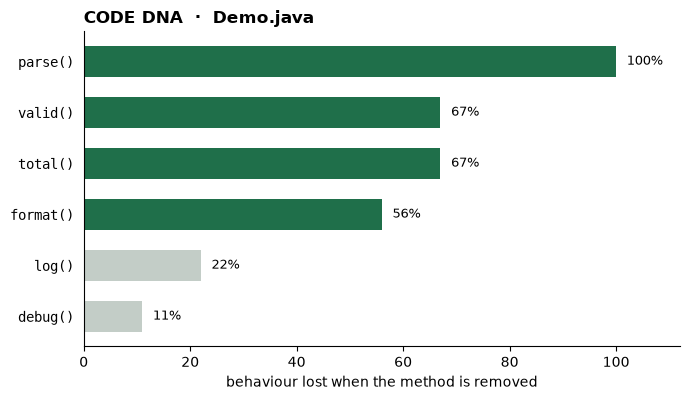

In [2]:
import re
import matplotlib.pyplot as plt

dna = [(gene, int(score)) for gene, score in re.findall(r"(\w+\(\))\s+.*?(\d+)%", report)]
genes, scores = zip(*reversed(dna))
rows = range(len(genes))

fig, ax = plt.subplots(figsize=(7, 0.45 * len(genes) + 1.4))
ax.barh(list(rows), scores, height=0.62,
        color=["#1f6f4a" if s >= 50 else "#c3cdc7" for s in scores])
for row, score in zip(rows, scores):
    ax.text(score + 2, row, f"{score}%", va="center", fontsize=9)

ax.set_yticks(list(rows), genes, fontfamily="monospace")
ax.set_xlim(0, 112)
ax.set_xlabel("behaviour lost when the method is removed")
ax.set_title("CODE DNA  ·  Demo.java", loc="left", fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(left=False)
plt.tight_layout()
plt.show()

Read from the top: without `parse()` the program does not survive at all. `valid()` and `total()`
carry the same weight — remove either and two thirds of the output changes. `format()` only affects
how results are printed, not whether they are right. `log()` and `debug()` are passengers: the
program computes exactly the same answers without them.

No test, assertion or annotation was written to produce this. It came out of the source file alone.

Point the analyser at your own file to profile it:

```bash
java -cp build CodeDNA path/to/YourClass.java
```